<a href="https://colab.research.google.com/github/shawn-maybush/3D-Kinematics-Analytics/blob/main/quaternion_ml_ik_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Inverse Kinematics with Dual Quaternions and Machine Learning



##System Check

In [26]:
from psutil import *
# This code will return the number of CPU
print("Number of CPU: ", cpu_count())
import psutil
split_bar = '='*20
memory_info = psutil.virtual_memory()._asdict()
print(f"{split_bar} Memory Usage {split_bar}")
for k,v in memory_info.items():
  print(k, v)
print(f"{split_bar} CPU Usage {split_bar}")
print(f"CPU percent: {psutil.cpu_percent()}%")

Number of CPU:  8
==================== Memory Usage ====================
total 54754004992
available 50133434368
percent 8.4
used 3995426816
free 44768522240
active 897830912
inactive 8633872384
buffers 462958592
cached 5527097344
shared 1593344
slab 275906560
==================== CPU Usage ====================
CPU percent: 3.4%


In [27]:
import os
os.environ["XLA_FLAGS"] = f'--xla_force_host_platform_device_count={cpu_count()}'

##Define Forward Kinematics

In [28]:
import sympy
import numpy as np
from IPython.display import display, Math
import pandas as pd
import ipyparallel as ipp
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.stats import qmc

import itertools

import jax.numpy as jnp
from jax import jit, pmap, vmap
from jax import random, debug
import jax
from jax import config
config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec as P
from functools import partial
from jax.experimental.shard_map import shard_map
from jax import lax


from typing import Sequence

In [29]:
jax.devices()

[CpuDevice(id=0),
 CpuDevice(id=1),
 CpuDevice(id=2),
 CpuDevice(id=3),
 CpuDevice(id=4),
 CpuDevice(id=5),
 CpuDevice(id=6),
 CpuDevice(id=7)]

In [30]:
cluster = ipp.Cluster(n=cpu_count())
rc = cluster.start_and_connect_sync()
dv = rc[:]
lv = rc.load_balanced_view()

Starting 8 engines with <class 'ipyparallel.cluster.launcher.LocalEngineSetLauncher'>


  0%|          | 0/8 [00:00<?, ?engine/s]

In [31]:
with rc[:].sync_imports():
  import sympy
  from math import pi, sqrt, degrees, radians
  import numpy
  from IPython.display import display, Math
  import pandas

importing sympy on engine(s)
importing pi,sqrt,degrees,radians from math on engine(s)
importing numpy on engine(s)
importing display,Math from IPython.display on engine(s)
importing pandas on engine(s)


In [32]:
def dualq_piecewise_simplify(dq):

  r = dq[0]
  d = dq[1]
  r_scalar = r.scalar_part()
  r_vector = r.to_Matrix(vector_only=True).T.tolist()

  r_list = [r_scalar] + r_vector[0]

  d_scalar = d.scalar_part()
  d_vector = d.to_Matrix(vector_only=True).T.tolist()
  d_list = [d_scalar] + d_vector[0]

  all = r_list + d_list

  all = lv.map_sync(lambda x: sympy.simplify(x), all)

  real_part = sympy.Quaternion(*all[:4])
  dual_part = sympy.Quaternion(*all[4:])

  result = sympy.Matrix([real_part, dual_part])

  return result

def dualq_piecewise_expand(dq):

  r = dq[0]
  d = dq[1]
  r_scalar = r.scalar_part()
  r_vector = r.to_Matrix(vector_only=True).T.tolist()

  r_list = [r_scalar] + r_vector[0]

  d_scalar = d.scalar_part()
  d_vector = d.to_Matrix(vector_only=True).T.tolist()
  d_list = [d_scalar] + d_vector[0]

  all = r_list + d_list

  all = lv.map_sync(lambda x: sympy.expand(x, basic=True), all)

  real_part = sympy.Quaternion(*all[:4])
  dual_part = sympy.Quaternion(*all[4:])

  result = sympy.Matrix([real_part, dual_part])

  return result

def dualq_piecewise_trigsimp(dq):

  r = dq[0]
  d = dq[1]
  r_scalar = r.scalar_part()
  r_vector = r.to_Matrix(vector_only=True).T.tolist()

  r_list = [r_scalar] + r_vector[0]

  d_scalar = d.scalar_part()
  d_vector = d.to_Matrix(vector_only=True).T.tolist()
  d_list = [d_scalar] + d_vector[0]

  all = r_list + d_list

  all = lv.map_sync(lambda x: sympy.trigsimp(x, basic=True), all)

  real_part = sympy.Quaternion(*all[:4])
  dual_part = sympy.Quaternion(*all[4:])

  result = sympy.Matrix([real_part, dual_part])

  return result

In [33]:
def dualq_mul(args):
    """
    Multiplies a list of dual quaternions.

    Args:
    args: A list of dual quaternions in Sympy Matrix format,
          where each dual quaternion is a 2x1 matrix with the
          real and dual parts as its elements.

    Returns:
    The product of the dual quaternions as a Sympy Matrix in expanded and simplified form.

    Raises:
    Exception: If less than 2 dual quaternions are provided.
    """

    if len(args) < 2:
        raise Exception("Need at least 2 dual quaternions to multiply")

    result = args[0]
    for i in range(1, len(args)):
        print(f"Multiplying {i + 1} of {len(args)}")

        dq_i = args[i]

        r1 = result[0]
        d1 = result[1]

        r2 = dq_i[0]
        d2 = dq_i[1]

        real_part = r1.mul(r2)
        dual_part = (r1.mul(d2)).add(d1.mul(r2))

        result = sympy.Matrix([real_part, dual_part])
        result = dualq_piecewise_expand(result)

    result = dualq_piecewise_trigsimp(result)
    return result

In [34]:
joints = [
    [[0,0,1],[0, 0, 0 ], False, (np.deg2rad(-90), np.deg2rad(90))],
    [[0,1,0],[3.3, 0, 0], False, (np.deg2rad(-90), np.deg2rad(90))],
    [[0,1,0],[10, 0, 0], False, (np.deg2rad(-90), np.deg2rad(90))],
    [[0,1,0],[12, 0, 0], True, ()]]

dq_joints = []
symbol_idx = 0
target_symbols = []

for joint in joints:
  if joint[2]:
    r = sympy.Quaternion.from_axis_angle(joint[0], 0)
  else:
    angle = sympy.symbols(f'theta_{symbol_idx}', real=True)
    symbol_idx += 1
    target_symbols.append(angle)
    r = sympy.Quaternion.from_axis_angle(joint[0], angle)

  t = sympy.Quaternion(0, joint[1][0], joint[1][1], joint[1][2])
  d = sympy.Rational(0.5) * t.mul(r)
  Q = sympy.Matrix([r, d])
  Q = dualq_piecewise_simplify(Q)
  dq_joints.append(Q)


In [35]:
foot_pose_dqi = dualq_mul(dq_joints)
foot_position_FK = (2 * foot_pose_dqi[1].mul(foot_pose_dqi[0].conjugate()))
foot_position_FK = foot_position_FK.to_Matrix(vector_only=True)
foot_orientation_FK = foot_pose_dqi[0].to_Matrix(vector_only=False)

Multiplying 2 of 4
Multiplying 3 of 4
Multiplying 4 of 4


In [36]:
foot_position_FK_lambda = sympy.lambdify(target_symbols, foot_position_FK, modules=['numpy'], cse=True, docstring_limit=0)
foot_orientation_FK_lambda = sympy.lambdify(target_symbols, foot_orientation_FK, modules=['numpy'], cse=True, docstring_limit=0)

In [37]:
n = 10000

data = pd.DataFrame()

param_ranges = {}

for i in range(len(target_symbols)):

  param_ranges[target_symbols[i]] = joints[i][3]

sampler = qmc.LatinHypercube(d=len(param_ranges))
samples = sampler.random(n=n)
scaled_samples = np.zeros_like(samples)


for i, (param_name, (lower, upper)) in enumerate(param_ranges.items()):
    scaled_samples[:, i] = qmc.scale(samples[:, i].reshape(-1, 1), lower, upper).flatten()

for i in range(n):

    position_x, position_y, position_z = foot_position_FK_lambda(*scaled_samples[i])
    orientation_w, orientation_x, orientation_y, orientation_z = foot_orientation_FK_lambda(*scaled_samples[i])
    feature_symbols = ['position_x', 'position_y', 'position_z','orientation_w', 'orientation_x', 'orientation_y', 'orientation_z']
    headers = target_symbols + feature_symbols
    row = np.concatenate((scaled_samples[i], position_x, position_y, position_z, orientation_w, orientation_x, orientation_y, orientation_z))
    row = pd.DataFrame([row], columns=headers)

    data = pd.concat([data, row], ignore_index=True)

In [38]:
data

,theta_0,theta_1,theta_2,position_x,position_y,position_z,orientation_w,orientation_x,orientation_y,orientation_z
0,1.345691,1.443399,1.528521,-1.619859,-7.074053,-11.945284,0.066267,-0.620973,0.779239,0.052808
1,-1.251364,0.541075,-0.743562,7.419344,-22.431219,-2.737295,0.806413,-0.059192,-0.081924,-0.582651
2,-0.978713,1.525545,1.548551,-4.587683,6.821054,-10.799111,0.029782,0.469790,0.882133,-0.015861
3,0.881026,1.191400,1.208406,-1.173165,-1.422106,-17.396159,0.327846,-0.397410,0.843028,0.154549
4,-0.874028,-0.141009,-0.692754,13.647214,-16.309233,10.291012,0.828424,-0.171373,-0.366857,-0.386989
...,...,...,...,...,...,...,...,...,...,...
9995,-1.219503,-1.213183,0.055034,3.996123,-10.903623,20.360093,0.686140,-0.313390,-0.448630,-0.479302
9996,-0.301763,-0.979520,-1.095862,2.934026,-0.913270,18.806795,0.502436,-0.129451,-0.851449,-0.076389
9997,0.667213,-0.498900,-0.523139,14.407473,11.349160,15.022674,0.824157,0.160146,-0.462103,0.285619
9998,1.491643,-1.348828,-0.813780,-0.094322,-1.189153,19.713835,0.345360,0.598892,-0.648276,0.319051


In [39]:
data.describe()

,theta_0,theta_1,theta_2,position_x,position_y,position_z,orientation_w,orientation_x,orientation_y,orientation_z
count,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.548207e-07,-0.000001,1.547237e-07,9.172122,0.035672,-0.015677,0.727322,0.000721,-0.000071,0.000413
std,9.069449e-01,0.906946,9.069444e-01,7.487555,11.927027,14.102431,0.206828,0.232454,0.496552,0.357313
min,-1.570567e+00,-1.570663,-1.570739e+00,-8.599254,-25.236568,-21.999492,0.013099,-0.702952,-0.998988,-0.706304
25%,-7.852330e-01,-0.785346,-7.852562e-01,2.761109,-8.808736,-13.854985,0.619138,-0.125113,-0.397684,-0.285086
50%,4.930645e-05,-0.000054,7.178686e-05,8.606781,0.042582,0.061117,0.770517,-0.000218,0.005855,0.000019
75%,7.854371e-01,0.785389,7.853600e-01,15.361316,8.636254,13.776496,0.887805,0.126615,0.403617,0.287151
max,1.570565e+00,1.570731,1.570613e+00,25.265834,25.223546,21.999175,0.999943,0.688297,0.997900,0.706493


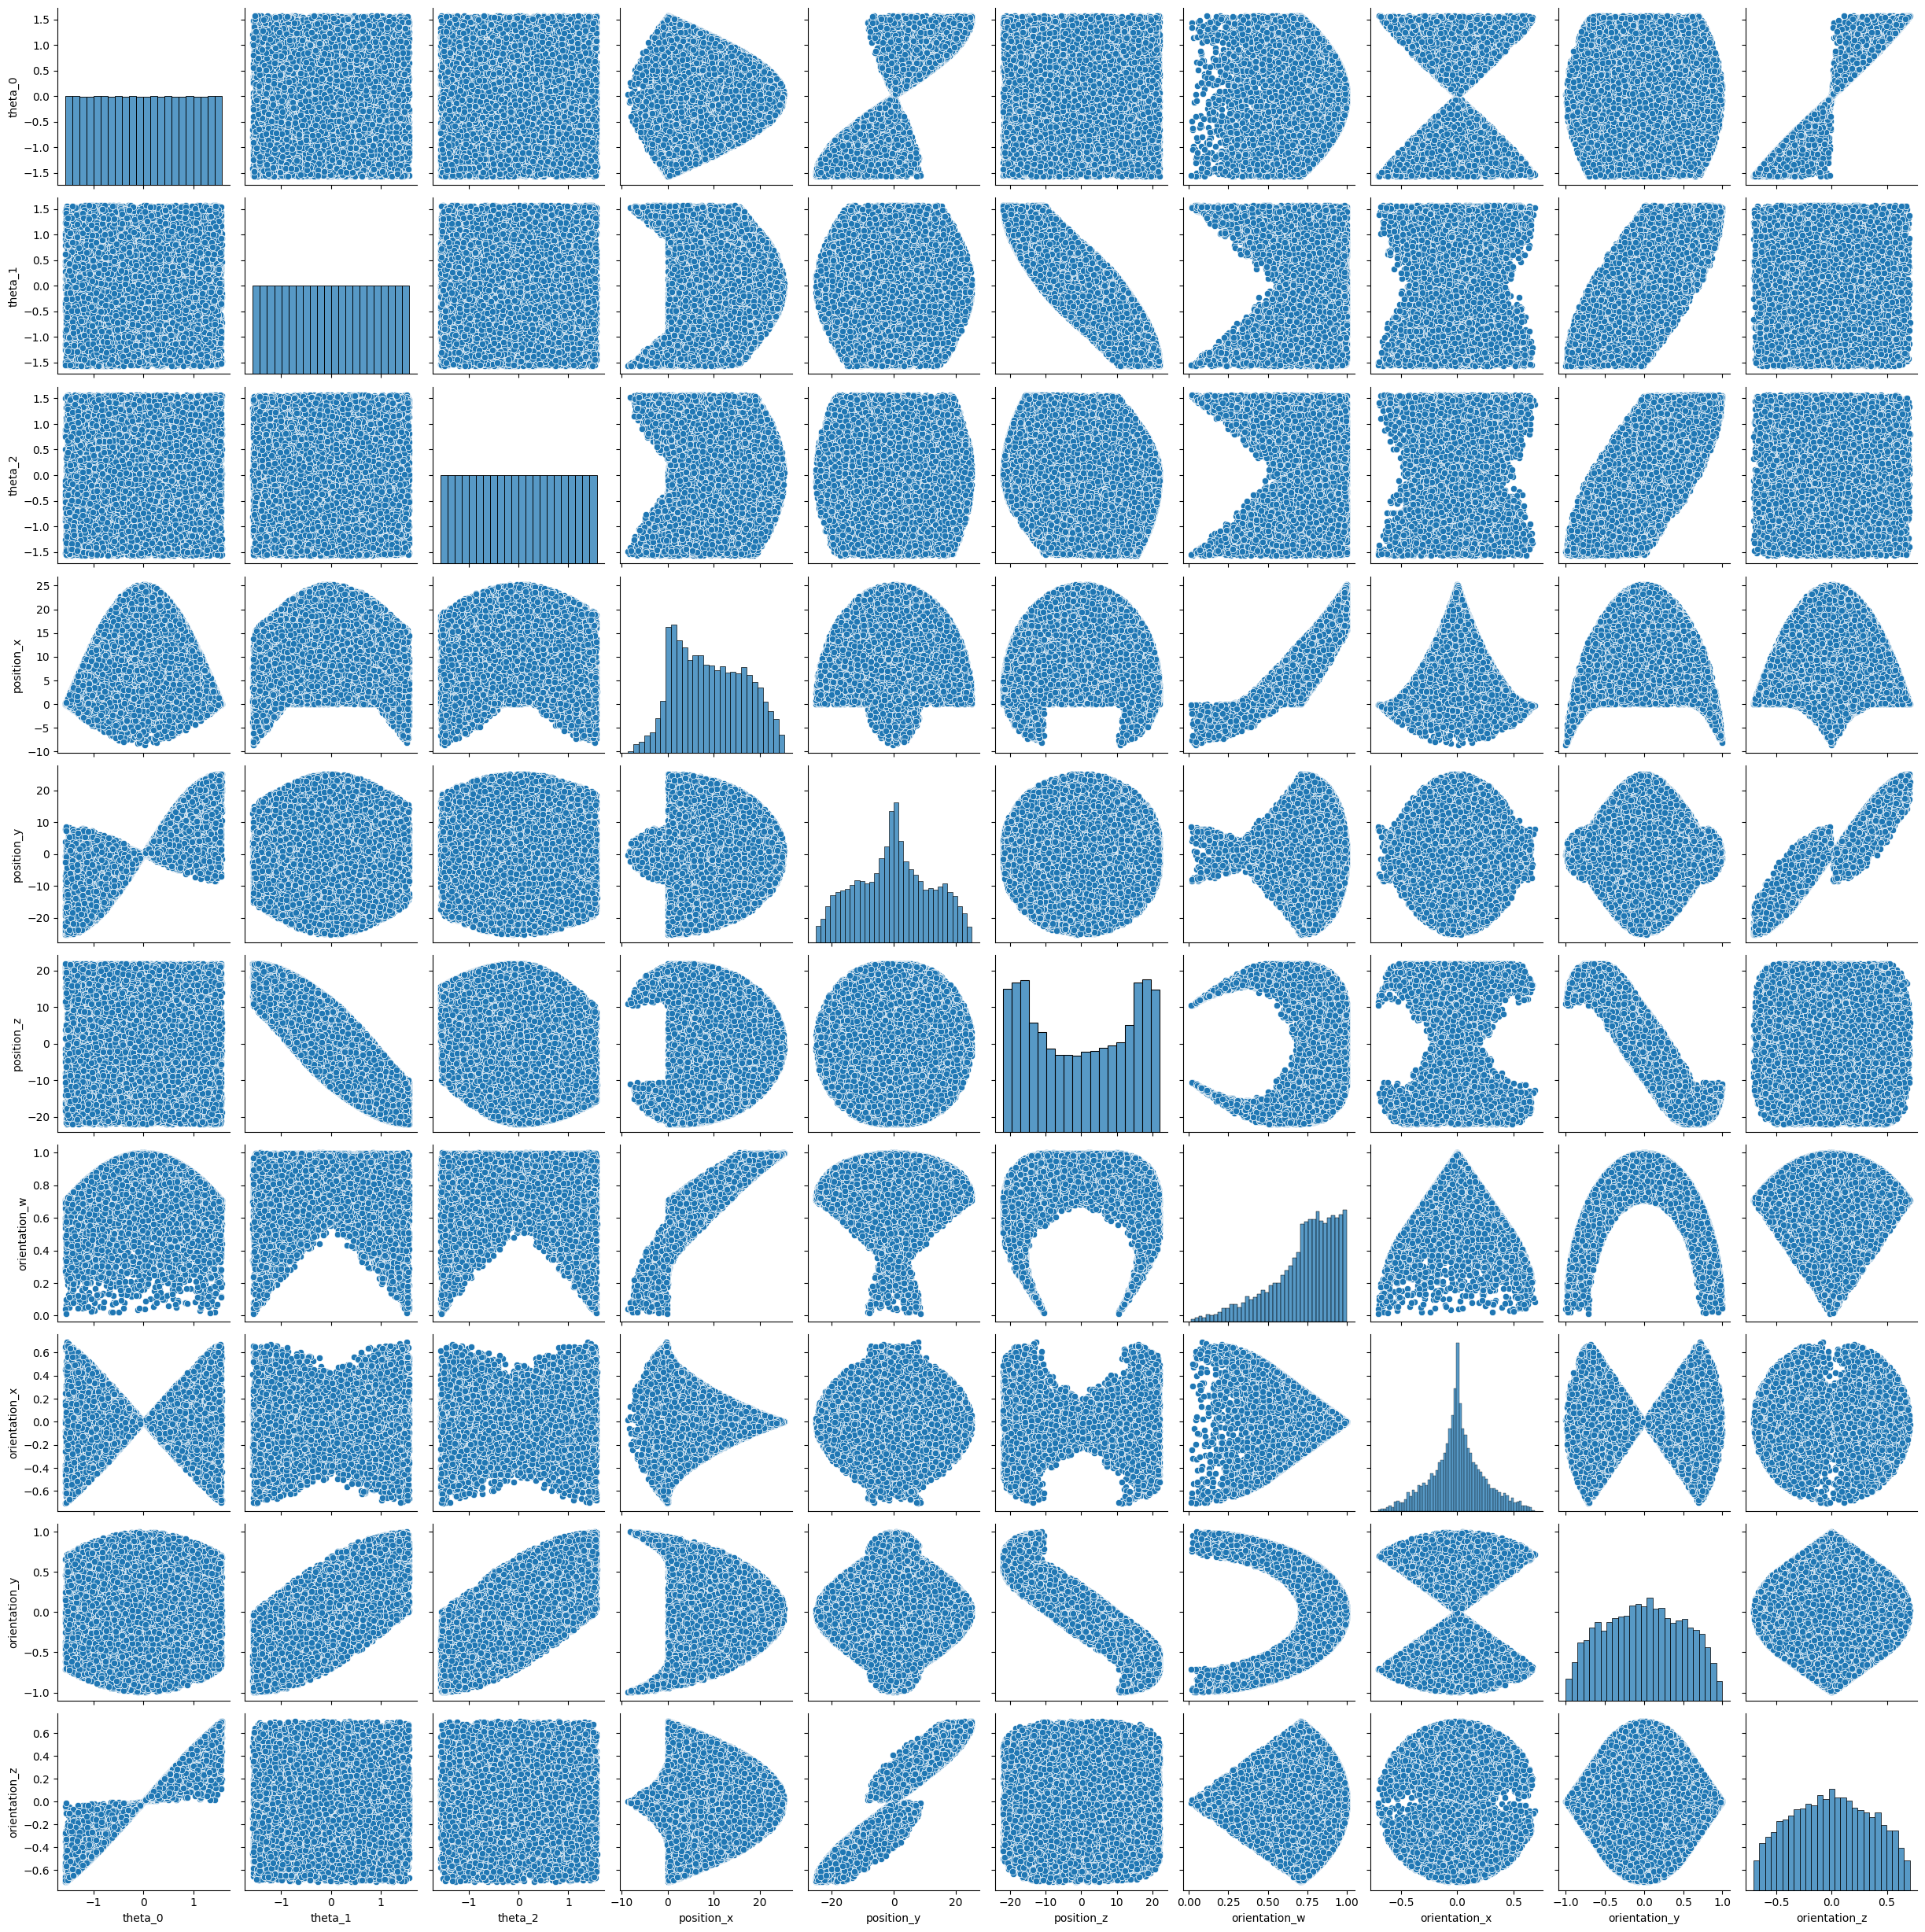

In [40]:
sns.pairplot(data)

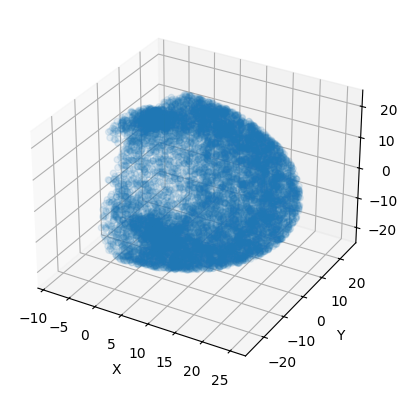

In [41]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['position_x'], data['position_y'], data['position_z'], alpha=0.1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [42]:
X = data.drop(target_symbols, axis=1)
y = data.drop(feature_symbols, axis=1)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [44]:
X_train

,position_x,position_y,position_z,orientation_w,orientation_x,orientation_y,orientation_z
9254,-0.793619,-0.136273,17.083004,0.367197,0.078946,-0.926258,0.031297
1561,9.577515,-13.527951,11.185025,0.886948,-0.024455,-0.047276,-0.458791
1670,11.504458,1.542792,-19.470633,0.894855,-0.029462,0.441360,0.059734
6087,13.117737,13.609933,-10.553419,0.788173,-0.201958,0.475150,0.335006
6669,7.318775,-17.640366,0.369022,0.786543,0.180367,0.270107,-0.525224
...,...,...,...,...,...,...,...
5734,0.056503,-0.107444,16.984215,0.328238,-0.477468,-0.790559,-0.198243
5191,7.847436,-17.000798,11.786329,0.837750,-0.056230,-0.087886,-0.535993
5390,-2.438237,-1.953437,14.793036,0.230717,0.321284,-0.914867,0.081023
860,10.101961,23.107103,-1.196957,0.836827,0.001667,-0.002548,0.547459


In [45]:
class polynomial_transformer:
  def __init__(self, degree=2, include_bias=True):
    self.degree = degree
    self.include_bias = include_bias

  @staticmethod
  @partial(jit, static_argnums=[1, 2])
  def __expand(Xp, include_bias, degree):
      n_samples, n_features = X.shape
      combinations = []
      for deg in range(1, degree + 1):
        combinations.extend(itertools.combinations_with_replacement(range(n_features), deg))
      n_samples, n_features = Xp.shape
      n_output_features = len(combinations)
      X_new = jnp.empty((n_samples, n_output_features), dtype=jnp.float64)
      for i, index_combi in enumerate(combinations):
        X_new = X_new.at[:, i].set(jnp.prod(Xp[:, index_combi], axis=1, dtype=jnp.float64))

      if include_bias:
        X_new = jnp.c_[jnp.ones(n_samples), X_new]
      return X_new

  def transform(self, X, y=None):
    X_new = self.__expand(X, self.include_bias, self.degree)
    return X_new


class Standard_Scaler:
    def __init__(self):
        self.mean = None
        self.std = None

    @staticmethod
    @jit
    def __j_fit(X):
      mean = jnp.mean(X, axis=0)
      std = jnp.std(X, axis=0)
      return mean, std

    def fit(self, X):
      self.mean, self.std = self.__j_fit(X)
      return self

    @staticmethod
    @jit
    def __j_transform(X, mean, std):
      X_scaled = (X - mean) / std
      return X_scaled

    def transform(self, X):
        X_scaled = self.__j_transform(X, self.mean, self.std)
        return X_scaled

    def inverse_transform(self, X_scaled):
        X = (X_scaled * self.std) + self.mean
        return X


class linear_regressor:
  def __init__(self, fit_intercept=True):
    self.weights = None
    self.bias = None
    self.fit_intercept = fit_intercept

  @staticmethod
  @partial(jit, static_argnums=[2])
  def __j_fit(X, y, fit_intercept):

      X_mean = jnp.mean(X, axis=0)

      y_mean = jnp.mean(y, axis=0)

      if fit_intercept:
        X_centered = X - X_mean
        y_centered = y - y_mean
        weights = jnp.linalg.lstsq(X_centered, y_centered)[0]
      else:
        weights = jnp.linalg.lstsq(X, y)[0]


      bias = y_mean - jnp.dot(X_mean, weights)
      return weights, bias

  def fit(self, X, y):
    self.weights, self.bias = self.__j_fit(X, y, self.fit_intercept)
    return self



  def predict(self, X):
    return jnp.dot(X, self.weights) + self.bias


In [46]:
X_train_jnp = jnp.array(X_train.values, dtype=np.float64)
y_train_jnp = jnp.array(y_train.values, dtype=np.float64)

X_test_jnp = jnp.array(X_test.values, dtype=np.float64)
y_test_jnp = jnp.array(y_test.values, dtype=np.float64)

scaler = Standard_Scaler()
scaler.fit(X.values)
X_train_jnp = scaler.transform(X_train_jnp)
X_test_jnp = scaler.transform(X_test_jnp)

poly = polynomial_transformer(degree=5, include_bias=True)
X_train_poly = poly.transform(X_train_jnp)

lr = linear_regressor(fit_intercept=True)
lr.fit(X_train_poly, y_train_jnp)

y_train_pred = lr.predict(X_train_poly)

X_test_poly = poly.transform(X_test_jnp)
y_pred = lr.predict(X_test_poly)

y_pred = np.asarray(y_pred)
y_train_pred = np.asarray(y_train_pred)

print(f'Training set score: {r2_score(y_train, y_train_pred):.3f}')
print(f'Test set score: {r2_score(y_test, y_pred):.3f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.3f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.3f}')

Training set score: 1.000
Test set score: 1.000
MSE: 0.000
MAE: 0.000


In [52]:
y_pred

array([[ 0.19084772, -0.7446333 ,  1.35752971],
       [-0.24071938, -0.51181288, -0.66521302],
       [-0.78184741, -1.06646621, -0.30789021],
       ...,
       [ 0.85081322, -0.11526074, -0.84905127],
       [-0.18896661,  0.45169305,  1.53451972],
       [ 1.45552905,  1.00937889, -0.18733248]])

In [47]:
@jit
def fit_fold(X, y, test_index, train_index):
  lr_cv = linear_regressor(fit_intercept=True)
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = y[train_index], y[test_index]
  lr_cv.fit(X_train, y_train)
  y_pred = lr_cv.predict(X_test)

  return y_test, y_pred



def cross_val_score_jax(X, y, k=5, random_state=None):

  key = random.PRNGKey(random_state) if random_state else random.PRNGKey(0)
  scores = []
  all_preds = []
  n_samples = len(X)


  shuffled_indices = random.permutation(key, jnp.arange(n_samples))
  fold_size = n_samples // k
  folds = [shuffled_indices[i * fold_size:(i + 1) * fold_size] for i in range(k)]

  for i in range(k):
    test_index = folds[i]
    train_index = jnp.concatenate([fold for j, fold in enumerate(folds) if j != i])
    y_test, y_pred = fit_fold(X, y, test_index, train_index)
    score = r2_score(np.asarray(y_test), np.asarray(y_pred))
    scores.append(score)

  scores = jnp.array(scores)
  mean_score = jnp.mean(scores)
  std_score = jnp.std(scores)

  return scores, mean_score, std_score


In [48]:
X_jnp = jnp.array(X.values, dtype=np.float64)
y_jnp = jnp.array(y.values, dtype=np.float64)
X_jnp = scaler.transform(X_jnp)
X_jnp = poly.transform(X_jnp)
scores, mean_score, std_score = cross_val_score_jax(X_jnp, y_jnp, k=5, random_state=42)
print(f'Scores: {scores}')
print(f'Mean score: {mean_score:.3f}')
print(f'Std score: {std_score:.3f}')

Scores: [0.99999998 0.99999997 0.99999998 0.99999997 0.99999998]
Mean score: 1.000
Std score: 0.000


In [49]:
np.save('scaler_mean.npy', scaler.mean)
np.save('scaler_std.npy', scaler.std)
np.save('weights.npy', lr.weights)
np.save('bias.npy', lr.bias)